# 01 — Exploratory Data Analysis

Understands the CP II-F dataset before modelling.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import load_csvs, clean, add_growth_features, add_bogue_features

# ── Set this to your CSV folder ───────────────────────────────────────────────
CSV_DIR = r'C:\Users\artemis.01\Desktop\AI_RESISTANCE\AI_RESISTANCE\PRODUCAO\CSV_PI'
# ─────────────────────────────────────────────────────────────────────────────

raw = load_csvs(CSV_DIR, prefix='cpii')
df  = clean(raw)
df  = add_growth_features(df)
df, derived = add_bogue_features(df)

print(f'Shape: {df.shape}')
print(f'\nDerived features: {derived}')
df.describe().round(2)

Shape: (916, 23)

Derived features: ['lsf', 'sm', 'blaine_so3']


,na2o,fe2o3,cao,so3,blaine,sio2,pf,#400,r.i,mgo,...,cs_7d,cs_28d,k2o,al2o3,growth_1d_3d,growth_3d_7d,growth_7d_28d,lsf,sm,blaine_so3
count,916.00,915.00,916.00,916.00,913.00,916.00,914.00,850.00,852.00,852.00,...,850.00,850.00,64.00,64.00,0.0,850.00,850.00,915.00,915.00,913.00
mean,0.04,2.76,59.72,2.91,4694.94,16.15,9.75,10.17,1.92,4.60,...,30.10,36.05,0.81,4.34,NaN,4.54,5.95,1.27,5.87,13661.41
std,0.12,0.17,1.16,0.20,323.86,0.93,1.17,1.94,0.62,0.73,...,1.92,2.61,0.07,0.23,NaN,1.16,1.58,0.08,0.59,1326.18
min,-0.27,1.95,54.11,2.47,3570.00,13.46,3.62,2.90,0.27,2.55,...,23.70,29.20,0.61,3.98,NaN,1.20,1.70,0.90,3.99,9174.90
25%,-0.08,2.67,58.90,2.77,4480.00,15.62,9.22,8.80,1.50,4.05,...,28.90,34.20,0.76,4.21,NaN,3.80,5.00,1.24,5.55,12730.00
50%,0.11,2.76,59.75,2.89,4680.00,16.07,10.01,10.20,1.82,4.58,...,30.10,36.00,0.82,4.30,NaN,4.50,5.80,1.28,5.79,13661.20
75%,0.12,2.84,60.56,3.01,4900.00,16.63,10.49,11.40,2.22,5.11,...,31.40,37.60,0.85,4.40,NaN,5.20,6.70,1.31,6.06,14512.40
max,0.17,3.97,62.56,3.61,5810.00,21.01,12.43,18.30,4.30,6.76,...,36.40,46.50,0.98,5.56,NaN,9.60,13.10,1.56,10.77,17991.20


## 1.1 Target distributions

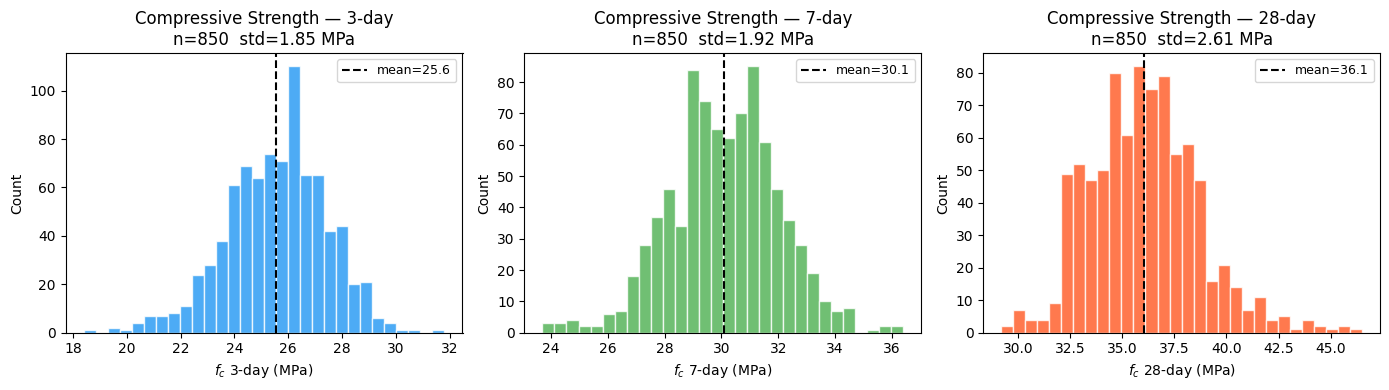

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
targets = [('cs_3d', '3-day', '#2196F3'), ('cs_7d', '7-day', '#4CAF50'), ('cs_28d', '28-day', '#FF5722')]
for ax, (col, label, color) in zip(axes, targets):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', lw=1.5, ls='--', label=f'mean={data.mean():.1f}')
    ax.set_xlabel(f'$f_c$ {label} (MPa)'); ax.set_ylabel('Count')
    ax.set_title(f'Compressive Strength — {label}\n'
                 f'n={len(data)}  std={data.std():.2f} MPa')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/fig_target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.2 Correlation matrix

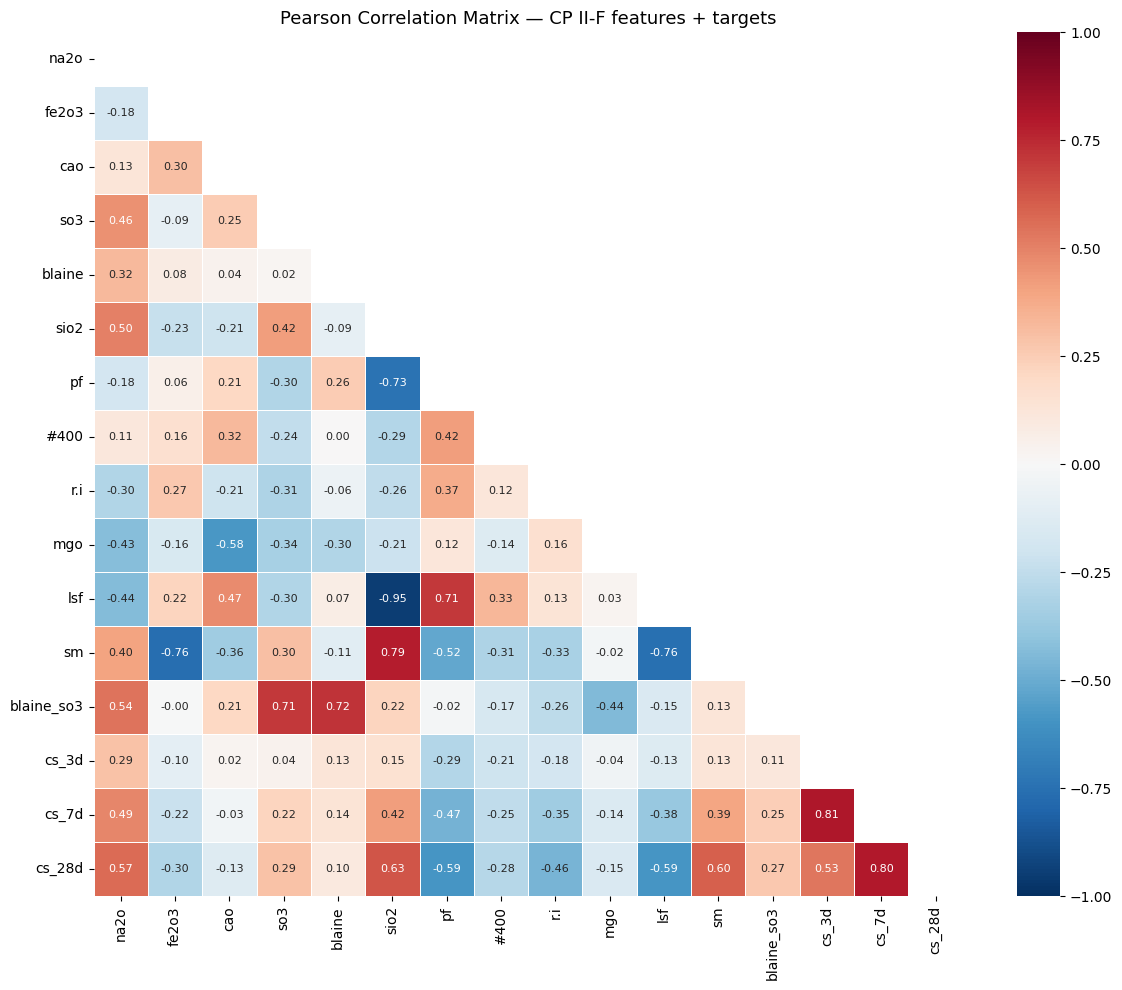

In [3]:
features = ['na2o','fe2o3','cao','so3','blaine','sio2','pf','#400','r.i','mgo',
            'lsf','sm','blaine_so3','cs_3d','cs_7d','cs_28d']
corr = df[[c for c in features if c in df.columns]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix — CP II-F features + targets', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Bogue features — scatter vs 3d strength

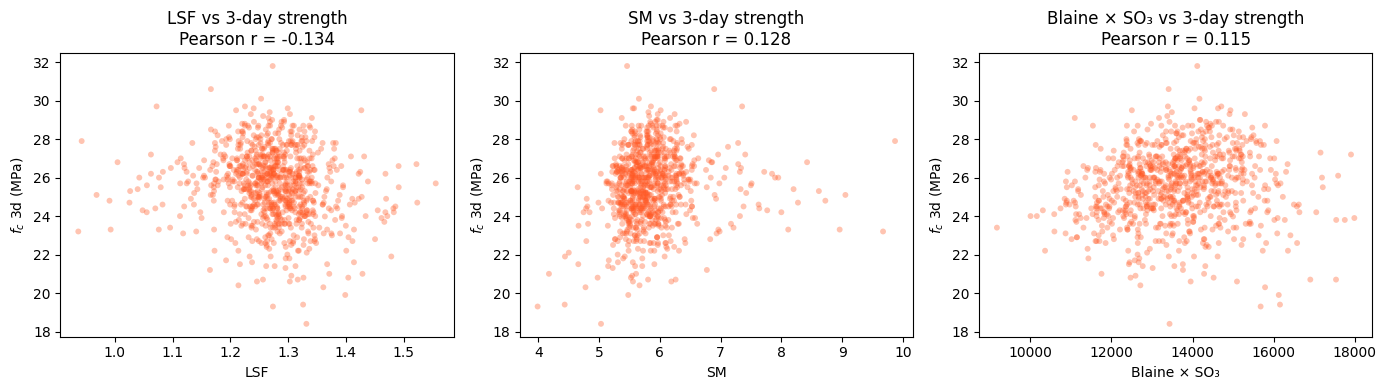

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bogue_feats = [('lsf', 'LSF'), ('sm', 'SM'), ('blaine_so3', 'Blaine × SO₃')]
for ax, (feat, label) in zip(axes, bogue_feats):
    sub = df[[feat, 'cs_3d']].dropna()
    ax.scatter(sub[feat], sub['cs_3d'], alpha=0.35, s=18, color='#FF5722', edgecolors='none')
    ax.set_xlabel(label); ax.set_ylabel('$f_c$ 3d (MPa)')
    r = sub.corr().iloc[0,1]
    ax.set_title(f'{label} vs 3-day strength\nPearson r = {r:.3f}')
plt.tight_layout()
plt.savefig('../figures/fig_bogue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Missing data profile

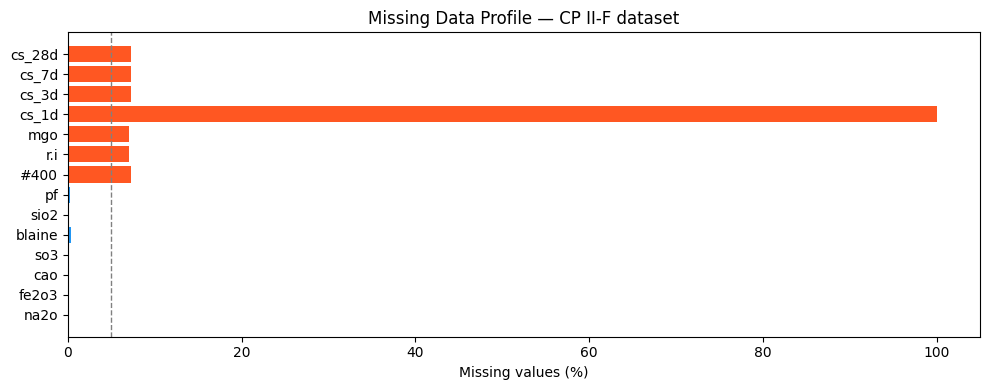

na2o        0.0
fe2o3       0.1
cao         0.0
so3         0.0
blaine      0.3
sio2        0.0
pf          0.2
#400        7.2
r.i         7.0
mgo         7.0
cs_1d     100.0
cs_3d       7.2
cs_7d       7.2
cs_28d      7.2


In [5]:
cols = ['na2o','fe2o3','cao','so3','blaine','sio2','pf','#400','r.i','mgo',
        'cs_1d','cs_3d','cs_7d','cs_28d']
nan_pct = df[[c for c in cols if c in df.columns]].isnull().mean() * 100
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#FF5722' if v > 5 else '#2196F3' for v in nan_pct.values]
ax.barh(nan_pct.index, nan_pct.values, color=colors)
ax.axvline(5, color='gray', ls='--', lw=1)
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing Data Profile — CP II-F dataset')
plt.tight_layout()
plt.savefig('../figures/fig_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()
print(nan_pct.round(1).to_string())